In [1]:
# Data Processing
import pandas as pd
import numpy as np

In [2]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [3]:
# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [4]:
cars = pd.read_csv('data/car.csv')

In [5]:
cars.shape

(1728, 7)

In [6]:
cars.head()

,price,maintenance,doors,seats,storage,safety,shouldBuy
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [7]:
cars.describe()

,price,maintenance,doors,seats,storage,safety,shouldBuy
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [8]:
cars.isnull().sum()

price          0
maintenance    0
doors          0
seats          0
storage        0
safety         0
shouldBuy      0
dtype: int64

In [9]:
for col in cars.columns:
    print(f"{col}: {cars[col].nunique()} unique values")
    print(cars[col].unique())
    print()

price: 4 unique values
['vhigh' 'high' 'med' 'low']

maintenance: 4 unique values
['vhigh' 'high' 'med' 'low']

doors: 4 unique values
['2' '3' '4' '5more']

seats: 3 unique values
['2' '4' 'more']

storage: 3 unique values
['small' 'med' 'big']

safety: 3 unique values
['low' 'med' 'high']

shouldBuy: 4 unique values
['unacc' 'acc' 'vgood' 'good']



In [10]:
from sklearn.preprocessing import OrdinalEncoder

# Define the explicit order for every column
categories = [
    ['low', 'med', 'high', 'vhigh'], # 1st: price
    ['low', 'med', 'high', 'vhigh'], # 2nd: maintenance
    ['2', '3', '4', '5more'],        # 3rd: doors
    ['2', '4', 'more'],              # 4th: seats
    ['small', 'med', 'big'],         # 5th: storage
    ['low', 'med', 'high']           # 6th: safety
]

encoder = OrdinalEncoder(categories=categories)
X_encoded = encoder.fit_transform(cars.iloc[:, :-1]) # All columns except target

In [11]:
# Typically for the target (y), we use LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(cars['shouldBuy'])

In [12]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
len(X_train), len(X_test)

(1382, 346)

In [14]:
rf = RandomForestClassifier()

In [15]:
rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = rf.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9913294797687862


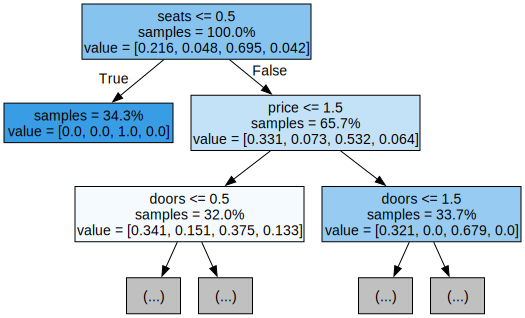

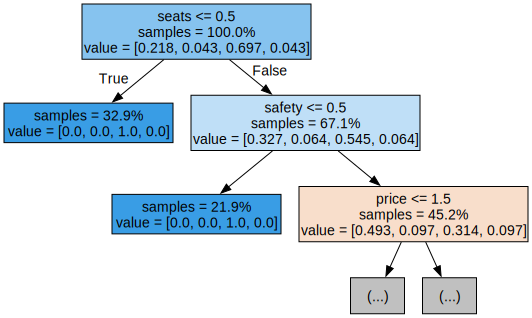

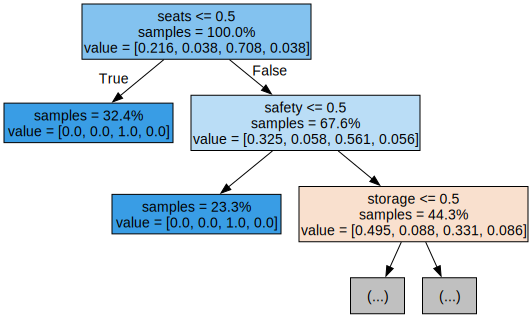

In [19]:
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=cars.columns[:-1],  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

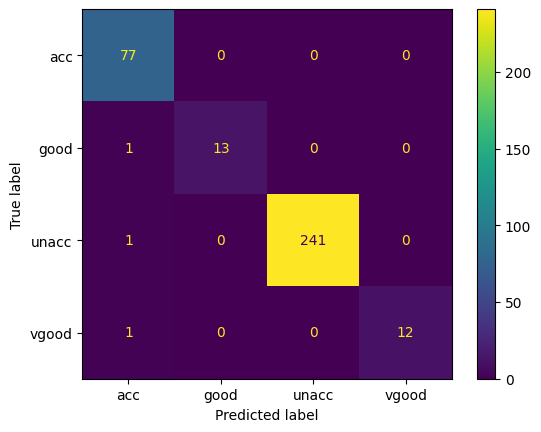

In [20]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

In [21]:
print(f"Training Accuracy: {rf.score(X_train, y_train)}")
print(f"Testing Accuracy: {rf.score(X_test, y_test)}")

Training Accuracy: 1.0
Testing Accuracy: 0.9913294797687862


In [22]:
rf1 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,       # Try limiting depth to 10
    min_samples_split=5, # Don't split if a node has very few samples
    random_state=42
)

In [23]:
rf1.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
print(f"New Training Accuracy: {rf1.score(X_train, y_train)}")
print(f"New Testing Accuracy: {rf1.score(X_test, y_test)}")

New Training Accuracy: 0.9978292329956585
New Testing Accuracy: 0.9797687861271677


In [25]:
from sklearn.model_selection import cross_val_score

# Use the model you just created
scores = cross_val_score(rf1, X_encoded, y, cv=5)

print(f"All Scores: {scores}")
print(f"Average Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

All Scores: [0.72254335 0.83815029 0.76878613 0.85507246 0.82318841]
Average Accuracy: 0.8015
Standard Deviation: 0.0490


In [26]:
rf2= RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    # min_samples_split=5,
    class_weight='balanced', # Automatically adjusts weights based on frequencies
    random_state=42
)

In [27]:
rf2.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
print(f"New Training Accuracy: {rf1.score(X_train, y_train)}")
print(f"New Testing Accuracy: {rf1.score(X_test, y_test)}")

New Training Accuracy: 0.9978292329956585
New Testing Accuracy: 0.9797687861271677


In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# This ensures each fold is a mini-replica of your pie chart
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf2, X_encoded, y, cv=skf)

print(f"Stratified CV Average: {scores.mean():.4f}")

Stratified CV Average: 0.9797


In [30]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    shuffle=True, 
    random_state=42, # Ensures reproducibility
    stratify=y  # Maintains the 70/22/4/4 ratio in both sets
)

In [31]:
rf3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [32]:
rf3.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
print(f"Post-Shuffle Training Accuracy: {rf3.score(X_train, y_train):.4f}")
print(f"Post-Shuffle Testing Accuracy: {rf3.score(X_test, y_test):.4f}")

Post-Shuffle Training Accuracy: 0.9964
Post-Shuffle Testing Accuracy: 0.9884


In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train1, y_train1)
y_pred_knn = knn.predict(X_test1)

accuracy = accuracy_score(y_test1, y_pred_knn)
precision = precision_score(y_test1, y_pred_knn, average='weighted')
recall = recall_score(y_test1, y_pred_knn, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.953757225433526
Precision: 0.9548568084174909
Recall: 0.953757225433526


<Axes: >

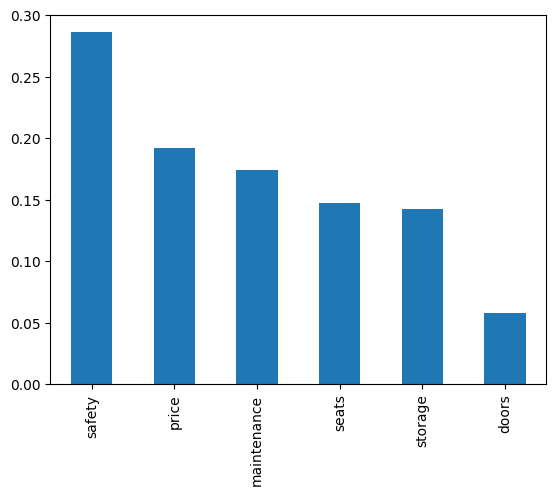

In [42]:
importances = pd.Series(rf3.feature_importances_, index=cars.iloc[:, :-1].columns)
importances.sort_values(ascending=False).plot.bar()